<a href="https://colab.research.google.com/github/alexb7z/instrumentacao/blob/main/pt100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PT100

Universidade Federal Rural do Semi-Árido (UFERSA) <br>
Disciplina: Instrumentação <br>
Docente: Francisco Carlos Gurgel da Silva Segundo <br>
Discente: Alex Bruno Duarte <br>

Uma indústria pretende utilizar um Pt100 para monitoramento de temperatura entre 0 °C e 100 °C. Antes da instalação, o setor de instrumentação realizou um ensaio de caracterização. O ensaio foi dividido em duas etapas. Na primeira etapa, o sensor foi submetido
a temperaturas de 0 a 100 °C, em passos de 5 °C. Em cada temperatura foram realizadas 5 medições durante o aquecimento e 5 durante o resfriamento. Na segunda etapa, o sensor foi mantido em 60 °C, realizando-se 120 medições, com intervalo de 2 segundos entre elas. <br>
O Pt100 possui nominalmente: <br>
𝑅₀ = 100Ω <br>
e coeficiente aproximadamente: <br>
𝛼 = 0,00385 º𝐶⁻¹ <br>
O objetivo é desenvolver uma rotina computacional que caracterize o
comportamento do sensor. Desenvolva uma rotina computacional que leia os arquivos fornecidos e realize
automaticamente as seguintes análises:


In [1]:
#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Links dos datasets no GitHub
URL_CALIBRACAO = (
    "https://raw.githubusercontent.com/alexb7z/instrumentacao/main/"
    "dataSet/pt100_calibracao_completa-sensor.csv"
)

URL_REPETIBILIDADE = (
    "https://raw.githubusercontent.com/alexb7z/instrumentacao/main/"
    "dataSet/pt100_repetibilidade_60C.csv"
)

# Leitura dos CSVs (separador ';').
# A coluna de resistência é lida como TEXTO (dtype=str) de propósito: no arquivo o
# separador decimal foi perdido (ex.: "10003667,00") e precisa ser tratado antes
# de virar número (veja a célula "Tratamento dos dados" mais abaixo).
df_calibracao = pd.read_csv(URL_CALIBRACAO, sep=';', dtype={'resistencia_ohm': str})
df_repetibilidade = pd.read_csv(URL_REPETIBILIDADE, sep=';', dtype={'resistencia_ohm': str})

# Parâmetros nominais do Pt100 (enunciado)
R0_NOM = 100.0        # Ω a 0 °C
ALFA_NOM = 0.00385    # 1/°C
S_NOM = R0_NOM * ALFA_NOM   # sensibilidade nominal = 0,385 Ω/°C

# Aparência padrão dos gráficos
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})
COR_AQ, COR_RES, COR_MED = '#d62728', '#1f77b4', 'black'   # cores: aquecimento, resfriamento, média

## 1. Organização dos dados

Separe as medições de aquecimento e resfriamento. Para cada temperatura de referência, calcule média, variância e desvio-padrão das cinco repetições. A rotina deverá gerar uma tabela final contendo T, média no aquecimento, média no resfriamento, desvio-padrão no aquecimento e desvio-padrão no resfriamento.

In [2]:
# Visualização inicial
print("Dataset de calibração:")
display(df_calibracao.head())

print("\nDataset de repetibilidade:")
display(df_repetibilidade.head())

Dataset de calibração:


,amostra,sentido,temperatura_referencia_C,repeticao,resistencia_ohm
0,1,aquecimento,0,1,"10003667,00"
1,2,aquecimento,0,2,"1000207,00"
2,3,aquecimento,0,3,"10002807,00"
3,4,aquecimento,0,4,"10001353,00"
4,5,aquecimento,0,5,"10002495,00"



Dataset de repetibilidade:


,amostra,tempo_s,temperatura_referencia_C,resistencia_ohm
0,1,0,60,"1232769,00"
1,2,2,60,"1232852,00"
2,3,4,60,"12327703,00"
3,4,6,60,"12328297,00"
4,5,8,60,"12327813,00"


### Tratamento dos dados (problema detectado nos CSVs)

Olhando as primeiras linhas, as resistências aparecem como `10003667,00`, `1000207,00`, `12327703,00`... Um Pt100 entre 0 e 100 °C deveria ter entre ≈100 Ω e ≈138,5 Ω, então os números **não** podem ser lidos diretamente (seriam ~10 milhões de ohms). O que aconteceu na exportação:

1. O separador decimal original foi perdido: `10003667` corresponde a **100,03667 Ω** (3 dígitos inteiros + 5 casas decimais). O `,00` final é só um artefato de formatação.
2. Alguns valores têm 7 dígitos em vez de 8 (ex.: `1000207`). Isso acontece quando o valor original terminava em zero (`100,02070`) e o zero final foi cortado na exportação. Basta completar com zeros à direita na parte decimal: `1000207` → `100,02070 Ω`.

A função abaixo reconstrói o valor correto e, em seguida, **valida** o resultado comparando com a curva nominal do Pt100 (`R = 100·(1 + 0,00385·T)`): se a reconstrução estiver certa, todas as leituras devem ficar a poucos décimos de ohm da curva nominal.

In [3]:
def corrige_resistencia(texto):
    """Reconstrói a resistência (Ω) a partir do texto corrompido do CSV.

    Regra: o Pt100 de 0 a 100 °C vai de 100 a ~138,5 Ω, ou seja, a parte inteira
    sempre tem 3 dígitos. O restante são casas decimais (5 casas, com os zeros
    finais que foram perdidos recompostos por ljust).
    """
    inteiro = str(texto).split(',')[0].strip()   # descarta o ",00" final
    parte_int = inteiro[:3]                      # 3 primeiros dígitos = parte inteira
    parte_dec = inteiro[3:].ljust(5, '0')        # completa com zeros à direita (5 casas)
    return float(f"{parte_int}.{parte_dec}")

# Aplica a correção e cria colunas numéricas padronizadas
df_calibracao['R_ohm'] = df_calibracao['resistencia_ohm'].apply(corrige_resistencia)
df_calibracao['T_ref'] = df_calibracao['temperatura_referencia_C']
df_repetibilidade['R_ohm'] = df_repetibilidade['resistencia_ohm'].apply(corrige_resistencia)

# ---- Validação: comparação com a curva nominal do Pt100 ----
dif_cal = df_calibracao['R_ohm'] - R0_NOM * (1 + ALFA_NOM * df_calibracao['T_ref'])
dif_rep = df_repetibilidade['R_ohm'] - R0_NOM * (1 + ALFA_NOM * 60)

print(f"Calibração:      {len(df_calibracao)} leituras | "
      f"{(df_calibracao['resistencia_ohm'].str.split(',').str[0].str.len() == 7).sum()} valores com zero final recomposto")
print(f"  R(0 °C)  = {df_calibracao.loc[df_calibracao.T_ref == 0, 'R_ohm'].mean():.3f} Ω | "
      f"R(100 °C) = {df_calibracao.loc[df_calibracao.T_ref == 100, 'R_ohm'].mean():.3f} Ω")
print(f"  desvio em relação ao nominal: de {dif_cal.min():+.3f} a {dif_cal.max():+.3f} Ω")
print(f"Repetibilidade:  {len(df_repetibilidade)} leituras | desvio em relação ao nominal em 60 °C: "
      f"de {dif_rep.min():+.3f} a {dif_rep.max():+.3f} Ω")

# Se a reconstrução estivesse errada, os desvios seriam de dezenas/centenas de ohms
assert dif_cal.abs().max() < 0.5 and dif_rep.abs().max() < 0.5, "Reconstrução inconsistente com o Pt100!"
print("\nOK: valores reconstruídos são consistentes com um Pt100 real.")

Calibração:      210 leituras | 18 valores com zero final recomposto
  R(0 °C)  = 100.031 Ω | R(100 °C) = 138.541 Ω
  desvio em relação ao nominal: de +0.006 a +0.216 Ω
Repetibilidade:  120 leituras | desvio em relação ao nominal em 60 °C: de +0.078 a +0.286 Ω

OK: valores reconstruídos são consistentes com um Pt100 real.


In [4]:
# --- 1. Separação aquecimento x resfriamento e estatísticas por temperatura ---
# groupby agrupa pelas 5 repetições de cada (temperatura, sentido).
# ATENÇÃO: .var() e .std() do pandas usam ddof=1 (estimador amostral, divide por n-1),
# que é o correto para n = 5 repetições.
estatisticas = (df_calibracao
                .groupby(['T_ref', 'sentido'])['R_ohm']
                .agg(media='mean', variancia='var', desvio_padrao='std')
                .unstack('sentido'))          # sentido vira coluna: (estatística, sentido)

print("Média, variância e desvio-padrão (5 repetições) por temperatura e sentido:")
display(estatisticas.style.format("{:.6f}"))

# Separação explícita dos dois sentidos (útil para os gráficos seguintes)
df_aq  = df_calibracao[df_calibracao['sentido'] == 'aquecimento']
df_res = df_calibracao[df_calibracao['sentido'] == 'resfriamento']
print(f"\nMedições de aquecimento: {len(df_aq)} | resfriamento: {len(df_res)}")

# Tabela final pedida no enunciado
tabela_final = pd.DataFrame({
    'T (°C)':                      estatisticas.index,
    'Média aquecimento (Ω)':       estatisticas[('media', 'aquecimento')].values,
    'Média resfriamento (Ω)':      estatisticas[('media', 'resfriamento')].values,
    'Desvio-padrão aquecimento (Ω)':  estatisticas[('desvio_padrao', 'aquecimento')].values,
    'Desvio-padrão resfriamento (Ω)': estatisticas[('desvio_padrao', 'resfriamento')].values,
})

print("\nTabela final:")
display(tabela_final.style.format({c: "{:.5f}" for c in tabela_final.columns if c != 'T (°C)'})
        .hide(axis='index'))

Média, variância e desvio-padrão (5 repetições) por temperatura e sentido:



Medições de aquecimento: 105 | resfriamento: 105

Tabela final:


T (°C),Média aquecimento (Ω),Média resfriamento (Ω),Desvio-padrão aquecimento (Ω),Desvio-padrão resfriamento (Ω)
0,100.02478,100.03672,0.00859,0.00512
5,101.97147,101.99217,0.00541,0.00536
10,103.91764,103.94138,0.01073,0.00801
15,105.86833,105.89269,0.00267,0.01088
20,107.80809,107.83697,0.00571,0.00885
25,109.74715,109.78116,0.00967,0.00764
30,111.68624,111.71307,0.01407,0.00562
35,113.62164,113.65938,0.00581,0.00421
40,115.55804,115.57914,0.00832,0.00894
45,117.48088,117.52227,0.00824,0.00741


**Leitura da tabela:** o desvio-padrão entre as 5 repetições fica na casa de 0,003 a 0,014 Ω (≈ 0,01 a 0,04 °C) em todas as temperaturas, sem tendência clara de crescimento com T, o que indica ruído de medição aproximadamente constante. Já a diferença entre as médias de aquecimento e resfriamento é bem maior que esse ruído nas temperaturas mais altas (retomado na seção 6).

## 2.  Curva característica do sensor

Construa no mesmo gráfico os pontos experimentais de aquecimento e resfriamento, utilizando temperatura no eixo x e resistência no eixo y. Em seguida, obtenha uma curva média do sensor.

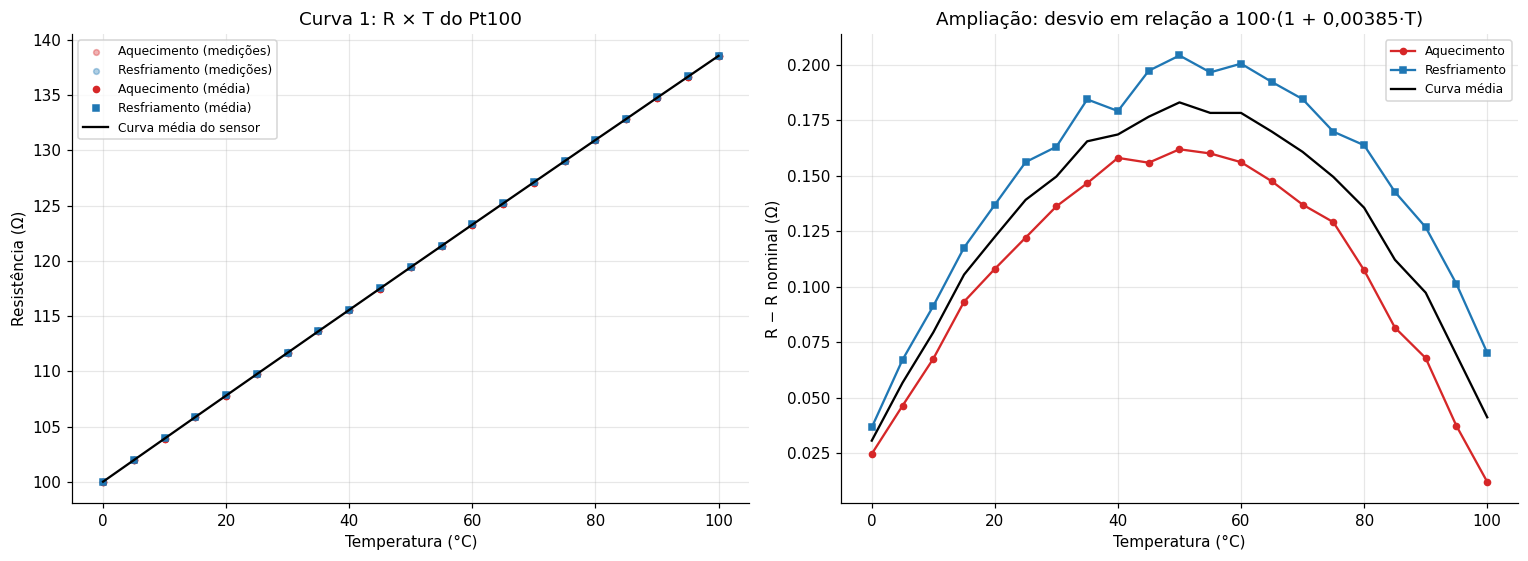

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
T (°C),0.0000,5.0000,10.0000,15.0000,20.0000,25.0000,30.0000,35.0000,40.0000,45.0000,50.0000,55.0000,60.0000,65.0000,70.0000,75.0000,80.0000,85.0000,90.0000,95.0000,100.0000
R média (Ω),100.0307,101.9818,103.9295,105.8805,107.8225,109.7642,111.6997,113.6405,115.5686,117.5016,119.4330,121.3533,123.2783,125.1949,127.1108,129.0245,130.9356,132.8372,134.7474,136.6443,138.5413


In [5]:
# --- 2. Curva característica R x T (Curva 1) ---
# Vetores com os valores médios de cada temperatura (vêm da tabela final)
T      = tabela_final['T (°C)'].to_numpy(dtype=float)
R_aq   = tabela_final['Média aquecimento (Ω)'].to_numpy()
R_res  = tabela_final['Média resfriamento (Ω)'].to_numpy()

# Curva média do sensor: média ponto a ponto entre aquecimento e resfriamento.
# Como os dois sentidos têm o mesmo nº de repetições (5), é equivalente à média das 10 leituras.
R_med = (R_aq + R_res) / 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2))

# (a) Pontos experimentais (todas as 210 leituras) + médias + curva média
ax1.scatter(df_aq['T_ref'],  df_aq['R_ohm'],  s=14, color=COR_AQ,  alpha=0.35, label='Aquecimento (medições)')
ax1.scatter(df_res['T_ref'], df_res['R_ohm'], s=14, color=COR_RES, alpha=0.35, label='Resfriamento (medições)')
ax1.plot(T, R_aq,  'o', color=COR_AQ,  ms=4, label='Aquecimento (média)')
ax1.plot(T, R_res, 's', color=COR_RES, ms=4, label='Resfriamento (média)')
ax1.plot(T, R_med, '-', color=COR_MED, lw=1.5, label='Curva média do sensor')
ax1.set_xlabel('Temperatura (°C)'); ax1.set_ylabel('Resistência (Ω)')
ax1.set_title('Curva 1: R × T do Pt100'); ax1.legend(fontsize=8)

# (b) Ampliação: desvio em relação à curva nominal (a diferença entre os sentidos
#     é de centésimos de ohm e fica invisível no gráfico (a) por causa da escala)
nominal = R0_NOM * (1 + ALFA_NOM * T)
ax2.plot(T, R_aq  - nominal, 'o-', color=COR_AQ,  ms=4, label='Aquecimento')
ax2.plot(T, R_res - nominal, 's-', color=COR_RES, ms=4, label='Resfriamento')
ax2.plot(T, R_med - nominal, '-',  color=COR_MED, lw=1.5, label='Curva média')
ax2.set_xlabel('Temperatura (°C)'); ax2.set_ylabel('R − R nominal (Ω)')
ax2.set_title('Ampliação: desvio em relação a 100·(1 + 0,00385·T)'); ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()

# Tabela da curva média (21 pontos) que será usada nas regressões
curva_media = pd.DataFrame({'T (°C)': T, 'R média (Ω)': R_med})
display(curva_media.T.style.format("{:.4f}"))

**Leitura:** na escala completa as duas curvas se sobrepõem (variação de ~38 Ω em 100 °C contra diferenças de centésimos de ohm). A ampliação à direita mostra o que o gráfico principal esconde: o sensor está levemente acima da curva nominal (+0,03 a +0,2 Ω), com formato curvo, e o resfriamento fica sempre acima do aquecimento. A curva média (preta) é a média das duas, e será usada nas regressões.

## 3. Função de transferência linear

Utilizando os dados médios, determine por regressão:<br>
*R(𝑇) = 𝑎𝑇 + 𝑏* <br>
Apresente *a*, *b*, *R²* e *RMSE*. Explique o significado físico dos coeficientes.


In [6]:
# --- 3. Regressão linear R(T) = a·T + b sobre a curva média ---
def metricas(y, y_ajustado):
    """Retorna (R², RMSE) de um ajuste."""
    ss_res = np.sum((y - y_ajustado) ** 2)        # soma dos quadrados dos resíduos
    ss_tot = np.sum((y - np.mean(y)) ** 2)        # soma total dos quadrados
    r2   = 1 - ss_res / ss_tot
    rmse = np.sqrt(np.mean((y - y_ajustado) ** 2))
    return r2, rmse

# np.polyfit(x, y, grau) faz mínimos quadrados e devolve coeficientes do maior grau p/ o menor
a_lin, b_lin = np.polyfit(T, R_med, 1)
R_lin = np.polyval([a_lin, b_lin], T)             # valores previstos pelo modelo linear
r2_lin, rmse_lin = metricas(R_med, R_lin)

print("Modelo linear: R(T) = a·T + b")
print(f"  a = {a_lin:.5f} Ω/°C")
print(f"  b = {b_lin:.4f} Ω")
print(f"  R² = {r2_lin:.6f}")
print(f"  RMSE = {rmse_lin:.4f} Ω  (≈ {rmse_lin / a_lin:.3f} °C)")

Modelo linear: R(T) = a·T + b
  a = 0.38516 Ω/°C
  b = 100.1191 Ω
  R² = 0.999984
  RMSE = 0.0471 Ω  (≈ 0.122 °C)


**Significado físico dos coeficientes**

- **a (inclinação) ≈ 0,385 Ω/°C** é a **sensibilidade** do sensor: quanto a resistência varia para cada 1 °C. Fisicamente vem de `a = R₀·α`, isto é, do coeficiente de temperatura da platina (α ≈ 0,00385 °C⁻¹) vezes a resistência a 0 °C. Quanto maior `a`, maior o sinal elétrico obtido para a mesma variação de temperatura.
- **b (intercepto) ≈ 100,12 Ω** é a resistência extrapolada para T = 0 °C, o equivalente experimental de **R₀** (nominal 100 Ω). O valor ficou ~0,12 Ω acima do nominal por dois motivos: o sensor real está ligeiramente deslocado (a medição direta em 0 °C dá ≈ 100,03 Ω) e a reta, ao tentar absorver a curvatura da platina, "sobe" o intercepto.

**R² ≈ 0,99998** indica que a reta explica praticamente toda a variação de R, mas R² é enganoso para linearidade, pois mesmo um ajuste com erro sistemático fica próximo de 1 quando a faixa de R é grande. O **RMSE ≈ 0,047 Ω (≈ 0,12 °C)** é a métrica mais informativa: o erro típico do modelo, em ohms.

## 4. Modelo não linear

Ajuste também um polinômio de segunda ordem: <br>
*𝑅(𝑇) = 𝑎𝑇² + 𝑏𝑇 + c* <br>
Calcule *R²* e *RMSE* e compare os dois modelos. Determine qual representa
melhor os dados.

Modelo quadrático: R(T) = a·T² + b·T + c
  a = -5.7525e-05 Ω/°C²
  b = 0.39091 Ω/°C
  c = 100.0281 Ω
  R² = 0.999999964
  RMSE = 0.00223 Ω  (≈ 0.0057 °C)


,R²,RMSE (Ω),RMSE (°C)
Linear,0.999983717,0.04706,0.1222
Quadrático,0.999999964,0.00223,0.0057



O RMSE do modelo quadrático é 21x menor que o do linear.

Comparação com Callendar-Van Dusen (IEC 60751):
  coef. de T²: ajustado = -5.752e-05 | teórico R0·B = -5.775e-05
  coef. de T : ajustado = 0.39091  | teórico R0·A = 0.39083


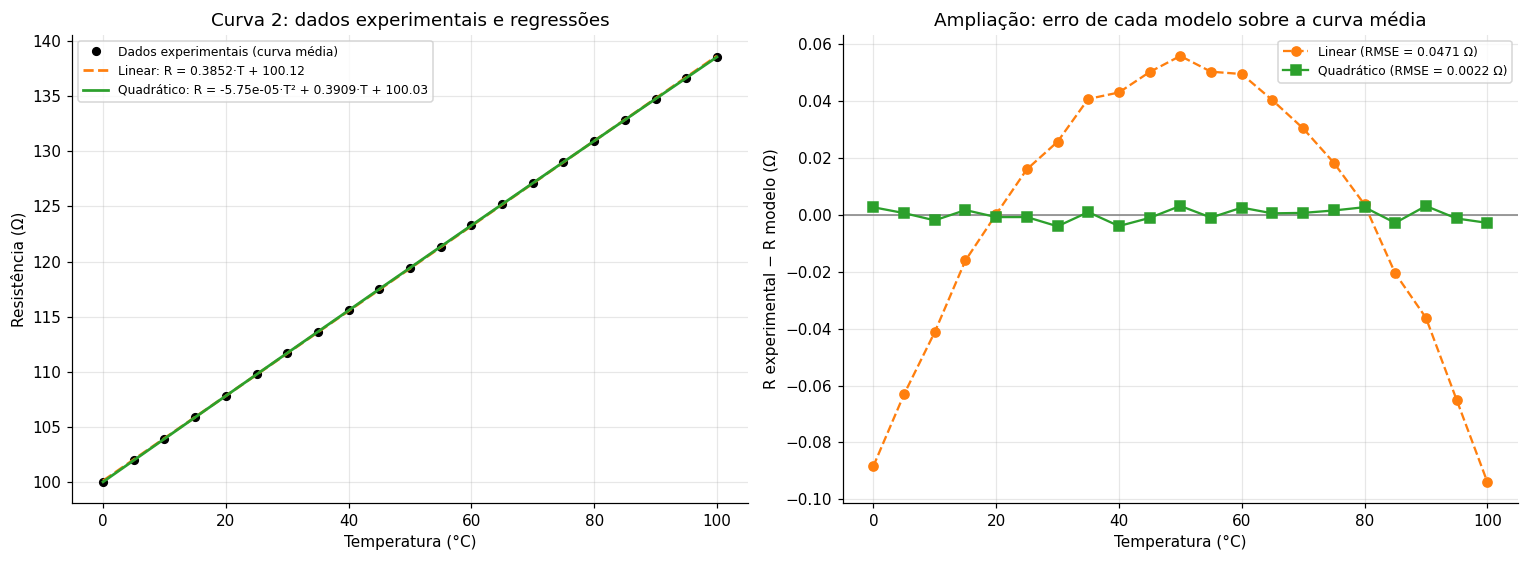

In [7]:
# --- 4. Regressão quadrática R(T) = a·T² + b·T + c ---
a_q, b_q, c_q = np.polyfit(T, R_med, 2)
R_quad = np.polyval([a_q, b_q, c_q], T)
r2_q, rmse_q = metricas(R_med, R_quad)

print("Modelo quadrático: R(T) = a·T² + b·T + c")
print(f"  a = {a_q:.4e} Ω/°C²")
print(f"  b = {b_q:.5f} Ω/°C")
print(f"  c = {c_q:.4f} Ω")
print(f"  R² = {r2_q:.9f}")
print(f"  RMSE = {rmse_q:.5f} Ω  (≈ {rmse_q / b_q:.4f} °C)")

# Comparação lado a lado
comparacao = pd.DataFrame({
    'R²':        [r2_lin,   r2_q],
    'RMSE (Ω)':  [rmse_lin, rmse_q],
    'RMSE (°C)': [rmse_lin / a_lin, rmse_q / b_q],
}, index=['Linear', 'Quadrático'])
display(comparacao.style.format({'R²': '{:.9f}', 'RMSE (Ω)': '{:.5f}', 'RMSE (°C)': '{:.4f}'}))
print(f"\nO RMSE do modelo quadrático é {rmse_lin / rmse_q:.0f}x menor que o do linear.")

# Comparação com a equação teórica de Callendar-Van Dusen (0 a 850 °C):
#   R(T) = R0·(1 + A·T + B·T²),  A = 3,9083e-3 °C⁻¹,  B = -5,775e-7 °C⁻²   (IEC 60751)
A_CVD, B_CVD = 3.9083e-3, -5.775e-7
print("\nComparação com Callendar-Van Dusen (IEC 60751):")
print(f"  coef. de T²: ajustado = {a_q:.3e} | teórico R0·B = {R0_NOM * B_CVD:.3e}")
print(f"  coef. de T : ajustado = {b_q:.5f}  | teórico R0·A = {R0_NOM * A_CVD:.5f}")

# ---- Curva 2: dados experimentais + regressão linear + regressão quadrática ----
T_fino = np.linspace(0, 100, 400)          # eixo fino para desenhar as curvas suaves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2))

ax1.plot(T, R_med, 'ko', ms=5, label='Dados experimentais (curva média)')
ax1.plot(T_fino, np.polyval([a_lin, b_lin], T_fino), '--', color='tab:orange', lw=1.8,
         label=f'Linear: R = {a_lin:.4f}·T + {b_lin:.2f}')
ax1.plot(T_fino, np.polyval([a_q, b_q, c_q], T_fino), '-', color='tab:green', lw=1.8,
         label=f'Quadrático: R = {a_q:.2e}·T² + {b_q:.4f}·T + {c_q:.2f}')
ax1.set_xlabel('Temperatura (°C)'); ax1.set_ylabel('Resistência (Ω)')
ax1.set_title('Curva 2: dados experimentais e regressões'); ax1.legend(fontsize=8)

# Ampliação: resíduos da curva média em relação a cada modelo (mostra a curvatura que a reta não captura)
ax2.axhline(0, color='gray', lw=1)
ax2.plot(T, R_med - R_lin,  'o--', color='tab:orange', label=f'Linear (RMSE = {rmse_lin:.4f} Ω)')
ax2.plot(T, R_med - R_quad, 's-',  color='tab:green',  label=f'Quadrático (RMSE = {rmse_q:.4f} Ω)')
ax2.set_xlabel('Temperatura (°C)'); ax2.set_ylabel('R experimental − R modelo (Ω)')
ax2.set_title('Ampliação: erro de cada modelo sobre a curva média'); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Qual modelo representa melhor os dados?** O **quadrático**. O gráfico da direita mostra a razão: o erro do modelo linear tem forma de "arco" (negativo nas pontas, positivo no meio, ou o inverso), um padrão sistemático que denuncia curvatura não capturada. Com o termo em T², o erro cai em ~20 vezes e passa a ser da ordem do ruído de medição somado à histerese. Além disso, os coeficientes ajustados batem muito bem com a equação teórica de Callendar-Van Dusen para a platina, o que confirma que a curvatura é uma propriedade física do Pt100, e não artefato do ajuste (o termo `a < 0` significa que a sensibilidade diminui levemente com a temperatura).

## 5. Sensibilidade

Determine a sensibilidade para o modelo linear e para o modelo quadrático. No modelo quadrático, calcule a sensibilidade nas temperaturas de 0, 25, 50, 75 e 100 °C. Compare os resultados com o valor nominal. <br>
*𝑆 ≈ 0,385 Ω/ºC*

In [8]:
# --- 5. Sensibilidade S = dR/dT ---
# Modelo linear: derivada de a·T + b é a constante a.
S_lin = a_lin
# Modelo quadrático: derivada de a·T² + b·T + c é S(T) = 2·a·T + b (varia com a temperatura).
def sens_quad(temp):
    return 2 * a_q * temp + b_q

print(f"Sensibilidade nominal:           S = {S_NOM:.4f} Ω/°C")
print(f"Modelo linear (constante):       S = {S_lin:.5f} Ω/°C  ({(S_lin / S_NOM - 1) * 100:+.2f} % em relação ao nominal)\n")

temps_sens = np.array([0, 25, 50, 75, 100])
tab_sens = pd.DataFrame({
    'T (°C)': temps_sens,
    'S quadrático (Ω/°C)': sens_quad(temps_sens),
    'S nominal (Ω/°C)': S_NOM,
})
tab_sens['Diferença (Ω/°C)'] = tab_sens['S quadrático (Ω/°C)'] - S_NOM
tab_sens['Diferença (%)'] = 100 * tab_sens['Diferença (Ω/°C)'] / S_NOM
display(tab_sens.style.format({'S quadrático (Ω/°C)': '{:.5f}', 'S nominal (Ω/°C)': '{:.3f}',
                               'Diferença (Ω/°C)': '{:+.5f}', 'Diferença (%)': '{:+.2f}'}).hide(axis='index'))

print(f"Variação da sensibilidade na faixa 0-100 °C: {sens_quad(0) - sens_quad(100):.4f} Ω/°C "
      f"({(sens_quad(0) - sens_quad(100)) / S_NOM * 100:.1f} % do valor nominal)")

Sensibilidade nominal:           S = 0.3850 Ω/°C
Modelo linear (constante):       S = 0.38516 Ω/°C  (+0.04 % em relação ao nominal)



T (°C),S quadrático (Ω/°C),S nominal (Ω/°C),Diferença (Ω/°C),Diferença (%)
0,0.39091,0.385,+0.00591,+1.54
25,0.38804,0.385,+0.00304,+0.79
50,0.38516,0.385,+0.00016,+0.04
75,0.38228,0.385,-0.00272,-0.71
100,0.37941,0.385,-0.00559,-1.45


Variação da sensibilidade na faixa 0-100 °C: 0.0115 Ω/°C (3.0 % do valor nominal)


**Comparação com o nominal (0,385 Ω/°C):** o modelo linear dá 0,3852 Ω/°C, praticamente igual ao nominal (+0,04 %), porque a reta devolve a sensibilidade *média* da faixa. O modelo quadrático mostra que a sensibilidade real **não é constante**: vai de ≈ 0,391 Ω/°C em 0 °C (+1,5 % acima do nominal) a ≈ 0,379 Ω/°C em 100 °C (−1,5 % abaixo). O valor nominal de 0,385 Ω/°C é, portanto, uma boa aproximação em torno de 50 °C, e a reta é adequada como valor médio, mas ela erra a sensibilidade local em até ~1,5 %.

## 6. Histerese

Para cada temperatura, determine: <br>
*H(𝑇) = |𝑅̅ resfriamento − 𝑅̅ aquecimento|* <br>
Construa um gráfico: <br>
*𝐻(Ω) × 𝑇(º𝐶)* <br>
Determine a maior histerese, a temperatura na qual ocorreu e converta o
resultado aproximadamente para °C utilizando a sensibilidade do sensor.

T (°C),H (Ω),H (°C) [H/S],Erro-padrão da diferença (Ω),H / erro-padrão
0.000000,0.0119,0.031,0.0045,2.7
5.000000,0.0207,0.054,0.0034,6.1
10.000000,0.0237,0.062,0.0060,4.0
15.000000,0.0244,0.063,0.0050,4.9
20.000000,0.0289,0.075,0.0047,6.1
25.000000,0.0340,0.088,0.0055,6.2
30.000000,0.0268,0.070,0.0068,4.0
35.000000,0.0377,0.098,0.0032,11.8
40.000000,0.0211,0.055,0.0055,3.9
45.000000,0.0414,0.107,0.0050,8.4



Maior histerese: 0.0639 Ω em T = 95 °C
  em °C usando S linear (0.3852 Ω/°C):       0.166 °C
  em °C usando S quadrático local (0.3800 Ω/°C): 0.168 °C
  em °C usando S nominal (0.385 Ω/°C):          0.166 °C
Resfriamento > aquecimento em 21 das 21 temperaturas
Histerese média: 0.0393 Ω (0.102 °C)


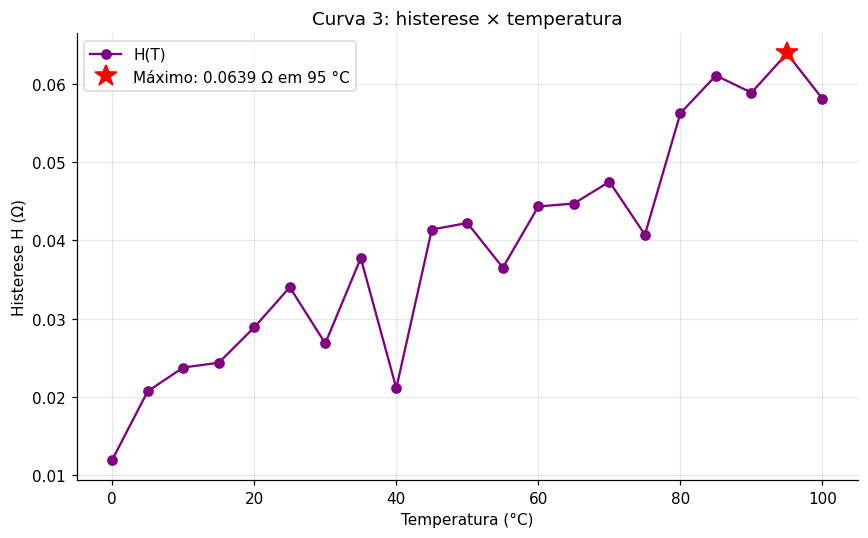

In [9]:
# --- 6. Histerese H(T) = |R_resfriamento - R_aquecimento| ---
H = np.abs(R_res - R_aq)

# Incerteza (erro-padrão) da diferença entre as duas médias de n=5: sqrt(s_aq²/5 + s_res²/5).
# Serve para saber se H é maior que o que o ruído sozinho explicaria.
s_aq  = tabela_final['Desvio-padrão aquecimento (Ω)'].to_numpy()
s_res = tabela_final['Desvio-padrão resfriamento (Ω)'].to_numpy()
ep_dif = np.sqrt(s_aq**2 / 5 + s_res**2 / 5)

tab_hist = pd.DataFrame({'T (°C)': T, 'H (Ω)': H, 'H (°C) [H/S]': H / S_lin,
                         'Erro-padrão da diferença (Ω)': ep_dif, 'H / erro-padrão': H / ep_dif})
display(tab_hist.style.format({'H (Ω)': '{:.4f}', 'H (°C) [H/S]': '{:.3f}',
                               'Erro-padrão da diferença (Ω)': '{:.4f}', 'H / erro-padrão': '{:.1f}'})
        .hide(axis='index'))

# Maior histerese e temperatura em que ocorreu
i_max = np.argmax(H)
H_max, T_Hmax = H[i_max], T[i_max]
# Conversão para °C: ΔT ≈ ΔR / S. Usa-se a sensibilidade linear (média) e, para comparação,
# a sensibilidade local do modelo quadrático e a nominal.
print(f"\nMaior histerese: {H_max:.4f} Ω em T = {T_Hmax:.0f} °C")
print(f"  em °C usando S linear ({S_lin:.4f} Ω/°C):       {H_max / S_lin:.3f} °C")
print(f"  em °C usando S quadrático local ({sens_quad(T_Hmax):.4f} Ω/°C): {H_max / sens_quad(T_Hmax):.3f} °C")
print(f"  em °C usando S nominal ({S_NOM:.3f} Ω/°C):          {H_max / S_NOM:.3f} °C")
print(f"Resfriamento > aquecimento em {np.sum(R_res > R_aq)} das {len(T)} temperaturas")
print(f"Histerese média: {H.mean():.4f} Ω ({H.mean() / S_lin:.3f} °C)")

# ---- Curva 3: H x T ----
plt.figure(figsize=(8, 5))
plt.plot(T, H, 'o-', color='purple', label='H(T)')
plt.plot(T_Hmax, H_max, 'r*', ms=15, label=f'Máximo: {H_max:.4f} Ω em {T_Hmax:.0f} °C')
plt.xlabel('Temperatura (°C)'); plt.ylabel('Histerese H (Ω)')
plt.title('Curva 3: histerese × temperatura'); plt.legend()
plt.tight_layout(); plt.show()

**Leitura:** a histerese **cresce praticamente de forma linear com a temperatura**, de ≈ 0,01 Ω em 0 °C até ≈ 0,06 Ω acima de 80 °C, e o resfriamento é *sempre* maior que o aquecimento. Essa diferença é muito maior que o ruído das médias (razão H/erro-padrão entre ≈ 9 e 19 acima de 80 °C), ou seja, **é um efeito real, não aleatório**. O sinal sempre igual e o crescimento com T são típicos de **atraso térmico** (o sensor não alcançava o equilíbrio com o banho antes da leitura: no aquecimento "fica atrás", no resfriamento "fica à frente") e não de histerese intrínseca da platina, que é desprezível em Pt100 de boa qualidade. Em termos de temperatura o efeito máximo é ≈ 0,17 °C.

## 7. Erro em relação ao modelo

Para cada medição, calcule o erro ou resíduo: <br>
*𝑒𝑖 = 𝑅𝑖 − R̂𝑖* <Br>
Construa um gráfico dos resíduos em função da temperatura. Discuta se os erros parecem aleatórios ou se existe alguma tendência sistemática.

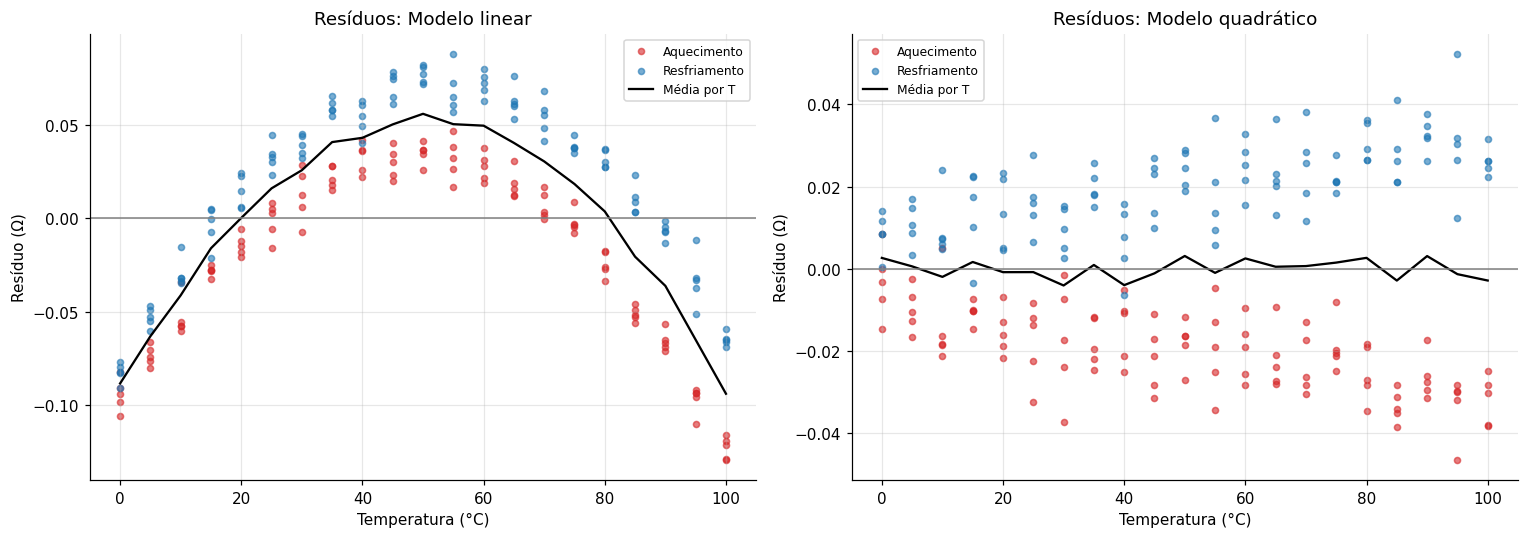

,Média do resíduo (Ω),Desvio-padrão (Ω),|e| máximo (Ω),Trocas de sinal da média por T
Linear,+0.00000,0.05210,0.12929,2
Quadrático,+0.00000,0.02224,0.05227,11


Resíduo médio do modelo quadrático por sentido (Ω):


,mean,std
sentido,,
aquecimento,-0.01964,+0.01025
resfriamento,+0.01964,+0.01048


In [10]:
# --- 7. Resíduos e_i = R_i - R_modelo(T_i) para CADA uma das 210 medições ---
df_cal = df_calibracao.copy()
df_cal['R_lin']  = np.polyval([a_lin, b_lin], df_cal['T_ref'])      # previsão do modelo linear
df_cal['R_quad'] = np.polyval([a_q, b_q, c_q], df_cal['T_ref'])     # previsão do modelo quadrático
df_cal['e_lin']  = df_cal['R_ohm'] - df_cal['R_lin']
df_cal['e_quad'] = df_cal['R_ohm'] - df_cal['R_quad']

fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, col, nome in zip(axs, ['e_lin', 'e_quad'], ['Modelo linear', 'Modelo quadrático']):
    for sentido, cor in [('aquecimento', COR_AQ), ('resfriamento', COR_RES)]:
        d = df_cal[df_cal['sentido'] == sentido]
        ax.scatter(d['T_ref'], d[col], s=16, color=cor, alpha=0.6, label=sentido.capitalize())
    media_por_T = df_cal.groupby('T_ref')[col].mean()          # tendência (média dos resíduos em cada T)
    ax.plot(media_por_T.index, media_por_T.values, 'k-', lw=1.5, label='Média por T')
    ax.axhline(0, color='gray', lw=1)
    ax.set_xlabel('Temperatura (°C)'); ax.set_ylabel('Resíduo (Ω)')
    ax.set_title(f'Resíduos: {nome}'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Indicadores numéricos para discutir aleatoriedade x tendência
def sinais_trocados(serie):
    """Conta quantas vezes a média dos resíduos troca de sinal ao longo de T (poucas trocas = tendência)."""
    s = np.sign(serie.values)
    return int(np.sum(s[1:] != s[:-1]))

resumo = pd.DataFrame({
    'Média do resíduo (Ω)': [df_cal['e_lin'].mean(), df_cal['e_quad'].mean()],
    'Desvio-padrão (Ω)':    [df_cal['e_lin'].std(), df_cal['e_quad'].std()],
    '|e| máximo (Ω)':       [df_cal['e_lin'].abs().max(), df_cal['e_quad'].abs().max()],
    'Trocas de sinal da média por T': [sinais_trocados(df_cal.groupby('T_ref')['e_lin'].mean()),
                                       sinais_trocados(df_cal.groupby('T_ref')['e_quad'].mean())],
}, index=['Linear', 'Quadrático'])
display(resumo.style.format({'Média do resíduo (Ω)': '{:+.5f}', 'Desvio-padrão (Ω)': '{:.5f}',
                             '|e| máximo (Ω)': '{:.5f}'}))

print("Resíduo médio do modelo quadrático por sentido (Ω):")
display(df_cal.groupby('sentido')['e_quad'].agg(['mean', 'std']).style.format('{:+.5f}'))

**Discussão dos erros**

- **Modelo linear:** os resíduos formam um **arco bem definido** em função de T (negativos nas extremidades e positivos no meio), com poucas trocas de sinal da média e amplitude entre ≈ −0,09 e +0,06 Ω, muito maior que o ruído (~0,008 Ω). Isso é uma **tendência sistemática** (erro de modelo, falta do termo quadrático), e não erro aleatório.
- **Modelo quadrático:** o arco desaparece e a média dos resíduos oscila em torno de zero. O que sobra é, em parte, ruído aleatório (desvio ≈ 0,02 Ω, com mesma ordem de grandeza do desvio entre repetições somado à histerese) e, em parte, **uma separação por sentido**: os resíduos de aquecimento ficam sistematicamente abaixo de zero e os de resfriamento acima, refletindo a histerese da seção 6. Como o modelo foi ajustado na média dos dois sentidos, ele não consegue (nem deveria) explicar essa separação.

## 8. Repetibilidade em 60 °C

Utilizando as 120 medições do segundo arquivo, calcule: <br>
*𝑅̅, s², s, CV* <br>
com: <br>
𝐶𝑉 = s/𝑅̅ × 100 <br>
Interprete o desvio-padrão e o coeficiente de variação em termos de repetibilidade.

n = 120 medições (intervalo de 2 s, duração 238 s)
  Média  R̄ = 123.27460 Ω
  Variância s² = 2.831e-04 Ω²
  Desvio-padrão s = 0.01683 Ω   (≈ 0.044 °C)
  CV = 0.0136 %
  Amplitude (máx - mín) = 0.2081 Ω
  Inclinação temporal (deriva): -1.50e-05 Ω/s  -> -0.0036 Ω ao longo do ensaio


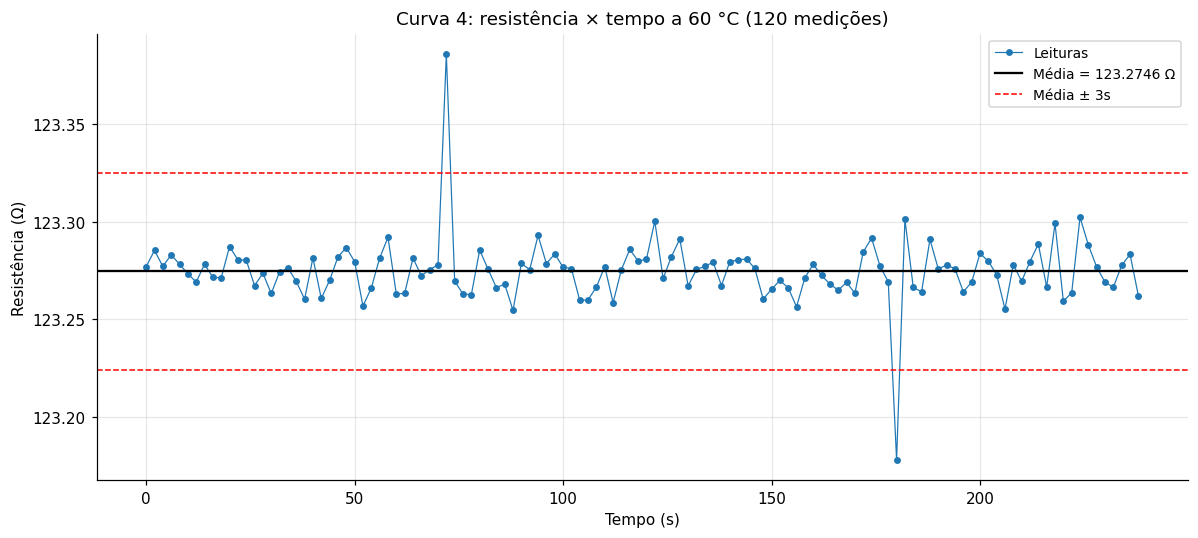

In [11]:
# --- 8. Repetibilidade em 60 °C (120 medições) ---
R60 = df_repetibilidade['R_ohm'].to_numpy()
t60 = df_repetibilidade['tempo_s'].to_numpy()

n = len(R60)
R_bar = R60.mean()                 # média
s2    = R60.var(ddof=1)            # variância amostral (divide por n-1)
s     = R60.std(ddof=1)            # desvio-padrão amostral
CV    = s / R_bar * 100            # coeficiente de variação em %

print(f"n = {n} medições (intervalo de {t60[1] - t60[0]:.0f} s, duração {t60[-1] - t60[0]:.0f} s)")
print(f"  Média  R̄ = {R_bar:.5f} Ω")
print(f"  Variância s² = {s2:.3e} Ω²")
print(f"  Desvio-padrão s = {s:.5f} Ω   (≈ {s / sens_quad(60):.3f} °C)")
print(f"  CV = {CV:.4f} %")
print(f"  Amplitude (máx - mín) = {R60.max() - R60.min():.4f} Ω")

# Verifica se há deriva (drift) temporal: regressão de R sobre o tempo
incl, _ = np.polyfit(t60, R60, 1)
print(f"  Inclinação temporal (deriva): {incl:.2e} Ω/s  -> {incl * (t60[-1] - t60[0]):+.4f} Ω ao longo do ensaio")

# ---- Curva 4: R x tempo ----
plt.figure(figsize=(11, 5))
plt.plot(t60, R60, 'o-', ms=3.5, lw=0.8, color='tab:blue', label='Leituras')
plt.axhline(R_bar, color='k', lw=1.5, label=f'Média = {R_bar:.4f} Ω')
plt.axhline(R_bar + 3 * s, color='r', ls='--', lw=1, label='Média ± 3s')
plt.axhline(R_bar - 3 * s, color='r', ls='--', lw=1)
plt.xlabel('Tempo (s)'); plt.ylabel('Resistência (Ω)')
plt.title('Curva 4: resistência × tempo a 60 °C (120 medições)'); plt.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Interpretação:** o desvio-padrão de ≈ 0,017 Ω equivale a apenas ≈ 0,04 °C, e o CV de ≈ 0,014 % mostra dispersão relativa muito pequena: o sensor tem **boa repetibilidade** (medições sucessivas, nas mesmas condições, concordam entre si dentro de poucos centésimos de ohm). O gráfico no tempo mostra um sinal estável, sem deriva perceptível, com dois pontos que escapam claramente da faixa (um acima e outro abaixo, ambos fora de ±3s), os quais inflam o desvio-padrão. 

Observação: o CV em ohms parece "bom demais" porque a resistência tem um grande offset (100 Ω em 0 °C). Para julgar a repetibilidade, vale mais olhar o desvio-padrão convertido em °C (≈ 0,04 °C) do que o CV em %.

## 9. Distribuição das medições

Construa um histograma das 120 leituras e represente sobre ele, se possível, uma distribuição normal com a mesma média e desvio-padrão. Determine quantas medições estão nos intervalos: <br>
𝑅̅ ± 𝜎 <br>
𝑅̅ ± 2𝜎 <br>
𝑅̅ ± 3𝜎 <br>
e compare os percentuais obtidos com a regra aproximada: <br>
68% − 95% − 99,7%

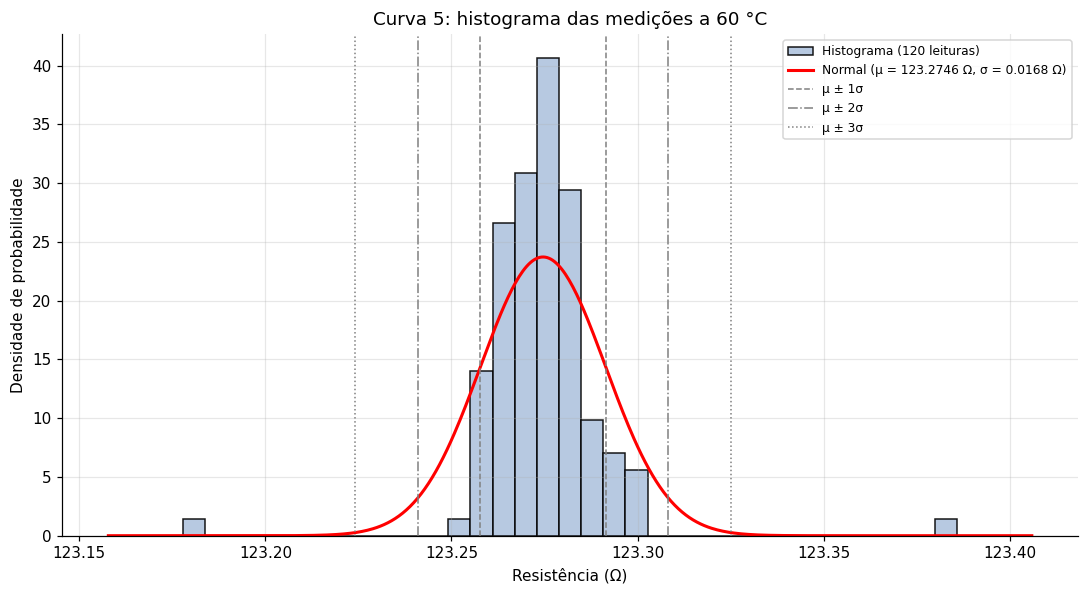

Intervalo,Limites (Ω),Nº de leituras,Obtido (%),Regra normal (%)
R̄ ± 1σ,123.2578 a 123.2914,107,89.2,68.0
R̄ ± 2σ,123.2410 a 123.3083,118,98.3,95.0
R̄ ± 3σ,123.2241 a 123.3251,118,98.3,99.7


In [12]:
# --- 9. Histograma e comparação com a distribuição normal (Curva 5) ---
# Usa-se a média R̄ e o desvio-padrão amostral s calculados na seção 8
mu, sigma = R_bar, s

plt.figure(figsize=(10, 5.5))
# density=True normaliza a área do histograma para 1, permitindo sobrepor a curva normal
plt.hist(R60, bins=35, density=True, color='lightsteelblue', edgecolor='k', alpha=0.9, label='Histograma (120 leituras)')

x = np.linspace(R60.min() - 0.02, R60.max() + 0.02, 500)
pdf = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))   # N(μ, σ²)
plt.plot(x, pdf, 'r-', lw=2, label=f'Normal (μ = {mu:.4f} Ω, σ = {sigma:.4f} Ω)')

for k, ls in [(1, '--'), (2, '-.'), (3, ':')]:
    plt.axvline(mu - k * sigma, color='gray', ls=ls, lw=1)
    plt.axvline(mu + k * sigma, color='gray', ls=ls, lw=1, label=f'μ ± {k}σ')
plt.xlabel('Resistência (Ω)'); plt.ylabel('Densidade de probabilidade')
plt.title('Curva 5: histograma das medições a 60 °C'); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Contagem de leituras em cada intervalo e comparação com a regra empírica 68-95-99,7
esperado = {1: 68.0, 2: 95.0, 3: 99.7}
linhas = []
for k in (1, 2, 3):
    dentro = int(np.sum(np.abs(R60 - mu) <= k * sigma))
    linhas.append({'Intervalo': f'R̄ ± {k}σ', 'Limites (Ω)': f'{mu - k * sigma:.4f} a {mu + k * sigma:.4f}',
                   'Nº de leituras': dentro, 'Obtido (%)': 100 * dentro / n, 'Regra normal (%)': esperado[k]})
display(pd.DataFrame(linhas).style.format({'Obtido (%)': '{:.1f}', 'Regra normal (%)': '{:.1f}'}).hide(axis='index'))

**Interpretação:** em ±1σ ficaram ≈ 89 % das leituras (esperado 68 %), em ±2σ ≈ 98 % (esperado 95 %) e em ±3σ ≈ 98 % (esperado 99,7 %). A distribuição é, portanto, **mais "concentrada" no centro e com caudas pesadas** em comparação a uma normal perfeita: a maior parte dos pontos está bem agrupada, mas há 2 pontos muito afastados, que inflam o σ (por isso ±1σ captura mais de 68 %) e ficam fora de 3σ. O núcleo do histograma é aproximadamente gaussiano, o que é coerente com ruído eletrônico aleatório; as caudas indicam eventos esporádicos (interferência, falha de leitura), tratados na próxima seção.

## 10. Detecção de valores anormais

Calcule o z-score de cada leitura: <br>
𝑧𝑖 = (𝑅𝑖 − 𝑅̅)/𝜎 <br>
Considere inicialmente como suspeitos valores com: <br>
|𝑧| > 3
Identifique esses dados. Depois, retire os valores considerados anormais e recalcule média, variância, desvio-padrão e coeficiente de variação. Discuta o efeito dos outliers sobre a análise estatística.

In [13]:
# --- 10. Detecção de valores anormais pelo z-score ---
# z_i = (R_i - R̄) / σ, usando média e desvio-padrão amostral das 120 leituras
df_rep = df_repetibilidade.copy()
df_rep['z'] = (df_rep['R_ohm'] - R_bar) / s

# Critério inicial: |z| > 3
suspeitos = df_rep[np.abs(df_rep['z']) > 3]
print(f"Valores suspeitos (|z| > 3): {len(suspeitos)} de {n}")
display(suspeitos[['amostra', 'tempo_s', 'R_ohm', 'z']].style.format({'R_ohm': '{:.5f}', 'z': '{:+.2f}'}).hide(axis='index'))

# Remove os suspeitos e recalcula as estatísticas
df_limpo = df_rep[np.abs(df_rep['z']) <= 3]
R60_limpo = df_limpo['R_ohm'].to_numpy()

def estatisticas_basicas(x):
    return {'n': len(x), 'Média (Ω)': x.mean(), 'Variância (Ω²)': x.var(ddof=1),
            'Desvio-padrão (Ω)': x.std(ddof=1), 'CV (%)': x.std(ddof=1) / x.mean() * 100}

comp = pd.DataFrame({'Com outliers': estatisticas_basicas(R60),
                     'Sem outliers': estatisticas_basicas(R60_limpo)})
comp['Variação (%)'] = 100 * (comp['Sem outliers'] / comp['Com outliers'] - 1)
display(comp.style.format({'Com outliers': '{:.6g}', 'Sem outliers': '{:.6g}', 'Variação (%)': '{:+.1f}'}))

# Verificação: ao remover os outliers, o σ diminui e novos pontos podem passar de 3σ ("efeito cascata").
z2 = (R60_limpo - R60_limpo.mean()) / R60_limpo.std(ddof=1)
print(f"Segunda passada: {np.sum(np.abs(z2) > 3)} ponto(s) com |z| > 3 nos dados já limpos "
      f"(máx |z| = {np.abs(z2).max():.2f}). Não se aplica nova remoção, para não descartar dados sem justificativa.")

Valores suspeitos (|z| > 3): 2 de 120


amostra,tempo_s,R_ohm,z
37,72,123.38595,+6.62
91,180,123.17780,-5.75


,Com outliers,Sem outliers,Variação (%)
n,120,118,-1.7
Média (Ω),123.275,123.274,-0.0
Variância (Ω²),0.000283087,0.000101852,-64.0
Desvio-padrão (Ω),0.0168252,0.0100922,-40.0
CV (%),0.0136486,0.00818675,-40.0


Segunda passada: 0 ponto(s) com |z| > 3 nos dados já limpos (máx |z| = 2.75). Não se aplica nova remoção, para não descartar dados sem justificativa.


**Efeito dos outliers:** foram identificados **2 valores anormais** (um em ≈ +6,6σ e outro em ≈ −5,8σ), separados do restante por 0,1 Ω, cerca de 6 vezes o desvio-padrão típico. Retirá-los não altera praticamente a média (a diferença é de ~10⁻⁴ Ω, pois um outlier positivo e um negativo se compensam), mas **reduz a variância em cerca de 64 % e o desvio-padrão em cerca de 40 % (de 0,0168 para 0,0101 Ω)**. Ou seja, os outliers afetam muito mais as medidas de **dispersão** do que a de posição: média é robusta quando os desvios se cancelam, mas s² e s dependem do quadrado dos desvios e são muito sensíveis a poucos pontos extremos. Como consequência, o desvio-padrão "com outliers" superestima a repetibilidade real do sensor.

O critério de |z| > 3 é só um **indício estatístico**: antes de descartar um dado definitivamente em uma aplicação real, convém investigar a causa (ruído de interferência, falha de contato, erro de aquisição). Aqui, dado o isolamento dos pontos, a hipótese de erro esporádico de leitura é bastante plausível.

## 11. Conversão resistência-temperatura

Inverta a função de transferência escolhida para transformar resistência em temperatura. Utilize essa função para converter as 120 leituras em °C e determine a temperatura média calculada. Compare com: <br>
𝑇referência = 60º𝐶 <br>
e determine o erro médio de medição.

Modelo quadrático (120 leituras): T média = 59.9971 °C | referência = 60 °C | erro médio = -0.0029 °C


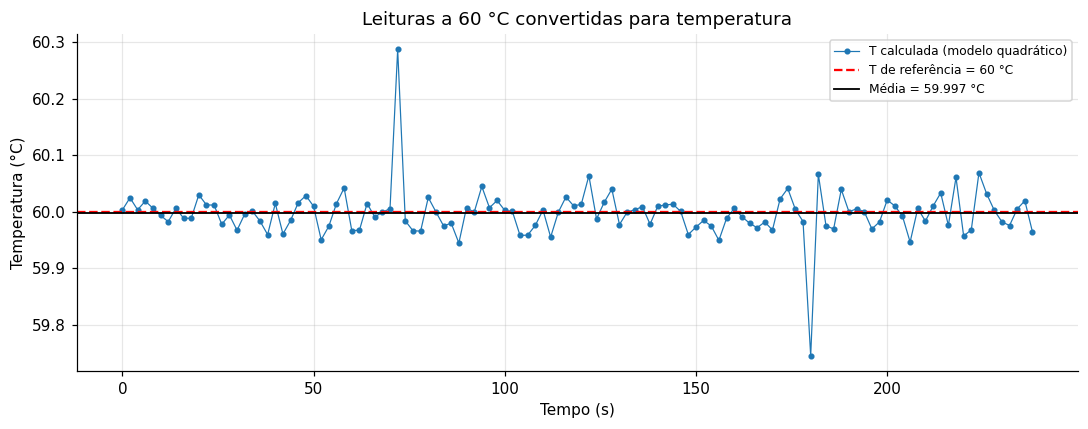

In [14]:
# --- 11. Conversão R -> T usando a função de transferência inversa ---
# Modelo adotado: QUADRÁTICO (menor RMSE e sem tendência sistemática nos resíduos, seções 4 e 7).
# Inversão de R = a·T² + b·T + c  ->  a·T² + b·T + (c - R) = 0  (equação do 2º grau em T):
#   T = [-b ± sqrt(b² - 4·a·(c - R))] / (2a)
# Como a < 0 e b > 0, a raiz com sinal "+" é a fisicamente válida (a outra fica longe da faixa 0-100 °C).
def R_para_T_quad(R):
    delta = b_q ** 2 - 4 * a_q * (c_q - R)
    return (-b_q + np.sqrt(delta)) / (2 * a_q)

# Para comparação, a inversa do modelo linear: T = (R - b)/a
def R_para_T_lin(R):
    return (R - b_lin) / a_lin

# Verificação de consistência: T -> R -> T deve devolver o valor original
assert np.allclose(R_para_T_quad(np.polyval([a_q, b_q, c_q], T_fino)), T_fino)

T_REF = 60.0
resultados = {}
for nome, R_entrada in [('Todas as 120 leituras', R60), ('Sem outliers (118)', R60_limpo)]:
    for modelo, f in [('Quadrático', R_para_T_quad), ('Linear', R_para_T_lin)]:
        T_calc = f(R_entrada)
        resultados[(nome, modelo)] = {'T média (°C)': T_calc.mean(), 'Desvio-padrão (°C)': T_calc.std(ddof=1),
                                      'Erro médio (°C)': T_calc.mean() - T_REF}
tab_conv = pd.DataFrame(resultados).T
display(tab_conv.style.format('{:+.4f}', subset=['Erro médio (°C)']).format('{:.4f}', subset=['T média (°C)', 'Desvio-padrão (°C)']))

# Resultado principal: modelo quadrático com as 120 leituras
T120 = R_para_T_quad(R60)
erro_medio = T120.mean() - T_REF
print(f"Modelo quadrático (120 leituras): T média = {T120.mean():.4f} °C | referência = {T_REF:.0f} °C | "
      f"erro médio = {erro_medio:+.4f} °C")

# Dispersão em °C das leituras convertidas
plt.figure(figsize=(10, 4))
plt.plot(t60, T120, 'o-', ms=3, lw=0.8, label='T calculada (modelo quadrático)')
plt.axhline(T_REF, color='r', ls='--', label='T de referência = 60 °C')
plt.axhline(T120.mean(), color='k', lw=1.2, label=f'Média = {T120.mean():.3f} °C')
plt.xlabel('Tempo (s)'); plt.ylabel('Temperatura (°C)')
plt.title('Leituras a 60 °C convertidas para temperatura'); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Interpretação:** com o modelo quadrático, a temperatura média calculada fica em ≈ 59,997 °C, ou seja, um **erro médio de ≈ −0,003 °C** (praticamente nulo) em relação aos 60 °C de referência. Com o modelo **linear**, o mesmo conjunto de leituras daria ≈ 60,12 °C (erro ≈ +0,12 °C), isto é, **cerca de 40 vezes pior**, o que mostra na prática o custo da curvatura ignorada. A dispersão das leituras convertidas é de ≈ 0,044 °C (com outliers) ou ≈ 0,026 °C (sem outliers). Como a curva foi ajustada na média entre aquecimento e resfriamento, o resultado esperado em 60 °C é o ponto intermediário entre os dois sentidos: a média das 120 leituras (123,275 Ω) fica de fato entre os valores de aquecimento (123,256 Ω) e de resfriamento (123,300 Ω) da calibração. O erro médio, praticamente nulo, é bem menor que a incerteza associada à histerese (≈ ±0,06 °C em torno da curva média nessa temperatura).

## 12. Conclusão técnica

Com base nos resultados, escreva uma conclusão respondendo: o sensor apresenta boa repetibilidade? Existe histerese perceptível? O comportamento é suficientemente linear? O modelo linear ou quadrático deve ser adotado? Existem valores discrepantes? E quais cuidados adicionais seriam necessários ao instalar esse Pt100 a 30 m de um painel industrial?


#### Cálculo auxiliar: cabo de 30 m entre o sensor e o painel
Para fundamentar o último item da conclusão, estima-se o erro causado pela resistência dos fios em uma ligação a **2 fios** (a resistência do cabo soma-se à do sensor e é interpretada como temperatura). Considera-se cobre (ρ ≈ 0,0172 Ω·mm²/m a 20 °C) e a ida e a volta (2 × 30 m).

In [15]:
# Erro de uma ligação a 2 fios com 30 m de cabo
RHO_CU = 0.0172          # Ω·mm²/m (cobre a 20 °C)
COMPR = 30               # m (distância do sensor ao painel)
S_USO = sens_quad(60)    # sensibilidade local usada para converter Ω em °C

linhas = []
for secao in [0.25, 0.5, 0.75, 1.0, 1.5]:           # seção do condutor em mm²
    R_cabo = RHO_CU * (2 * COMPR) / secao            # resistência da malha (ida + volta)
    linhas.append({'Seção (mm²)': secao, 'R do cabo ida+volta (Ω)': R_cabo, 'Erro a 2 fios (°C)': R_cabo / S_USO})
display(pd.DataFrame(linhas).style.format({'R do cabo ida+volta (Ω)': '{:.2f}', 'Erro a 2 fios (°C)': '{:.1f}'}).hide(axis='index'))

# Para comparar: a histerese máxima e o desvio de repetibilidade medidos são da ordem de décimos de °C
print(f"Referência: histerese máx. ≈ {H_max / S_lin:.2f} °C | desvio-padrão da repetibilidade ≈ {s / S_USO:.3f} °C")

Seção (mm²),R do cabo ida+volta (Ω),Erro a 2 fios (°C)
0.250000,4.13,10.7
0.500000,2.06,5.4
0.750000,1.38,3.6
1.000000,1.03,2.7
1.500000,0.69,1.8


Referência: histerese máx. ≈ 0.17 °C | desvio-padrão da repetibilidade ≈ 0.044 °C


### Conclusão técnica

**Repetibilidade.** O sensor apresenta **boa repetibilidade**. Em 60 °C, as 120 leituras têm desvio-padrão de 0,017 Ω (≈ 0,044 °C) e CV de 0,014 %, sem deriva temporal perceptível (≈ −0,004 Ω em 4 min). Retirando 2 valores anormais, o desvio-padrão cai para ≈ 0,010 Ω (≈ 0,026 °C). Na calibração, o desvio entre as 5 repetições ficou entre 0,003 e 0,014 Ω em todas as temperaturas.

**Histerese.** **Existe histerese perceptível**, embora pequena: de 0,012 Ω em 0 °C até um máximo de **0,064 Ω (≈ 0,17 °C) em 95 °C**. O resfriamento é maior que o aquecimento nas 21 temperaturas, e a diferença cresce com T e é bem maior que o ruído das médias. Esse comportamento sugere **atraso térmico** (tempo de estabilização insuficiente no ensaio) mais do que histerese intrínseca do material. Para uma aplicação de 0 a 100 °C, o efeito é pequeno, mas deve entrar no balanço de incertezas se for necessária exatidão melhor que ±0,2 °C.

**Linearidade e modelo.** O comportamento é **aproximadamente linear, mas não o suficiente para uma exatidão melhor que ≈ 0,1 °C**. A reta tem R² = 0,99998, mas RMSE de 0,047 Ω (≈ 0,12 °C) e resíduos sistemáticos em forma de arco (−0,09 a +0,06 Ω). A sensibilidade varia ≈ 3 % na faixa (0,391 Ω/°C em 0 °C a 0,379 Ω/°C em 100 °C), enquanto o nominal é 0,385 Ω/°C. O **modelo quadrático** reduz o RMSE para 0,0022 Ω (≈ 0,006 °C), elimina a tendência nos resíduos e reproduz os coeficientes teóricos da platina (Callendar-Van Dusen). **Recomenda-se adotar o modelo quadrático** (e sua inversa) na conversão de R para T. A reta só se justifica se um erro de até ≈ 0,12 °C for aceitável (ou em um intervalo menor, em torno de 50 °C).

**Valores discrepantes.** Sim: **2 leituras em 120** (1,7 %) ficaram além de 3σ (z = +6,6 e −5,8), distantes ≈ 0,1 Ω do restante. Elas não alteram a média, mas aumentam a variância em ≈ 64 % (o desvio-padrão em ≈ 40 %). São compatíveis com ruído/interferência esporádica e devem ser tratadas (filtro, mediana, rejeição) em um sistema real. Convertendo as leituras com o modelo quadrático, a temperatura média ficou em 59,997 °C (erro médio de −0,003 °C em relação aos 60 °C).

**Cuidados na instalação a 30 m do painel.**
- **Resistência dos fios:** em ligação a **2 fios**, 30 m de cobre (ida e volta) somam 0,7 a 4 Ω conforme a seção, o que equivale a **1,8 a 10 °C de erro** (ver tabela acima), maior que todos os efeitos medidos neste ensaio. Usar **3 fios** (compensa o cabo se os condutores forem idênticos) ou, de preferência, **4 fios** (elimina o efeito), ou um **transmissor 4-20 mA** montado junto ao sensor, que também reduz a sensibilidade ao ruído no trajeto.
- **Interferência eletromagnética:** o sinal é de poucos décimos de ohm por °C. Usar cabo **blindado e par trançado**, aterrar a malha em apenas uma extremidade (normalmente no painel) e afastar o cabo de potência, inversores e motores. Isso reduz as leituras anômalas como as detectadas.
- **Autoaquecimento:** limitar a corrente de excitação (tipicamente ≤ 1 mA) para que a dissipação no sensor não gere erro.
- **Variação da temperatura do cabo e conexões:** o cobre varia ≈ 0,39 %/°C; conexões frouxas ou oxidadas inserem resistência de contato. Usar terminais adequados e boa vedação.
- **Dinâmica térmica:** a histerese observada indica que o sensor precisa de tempo para estabilizar. Considerar poço termométrico, pasta térmica e tempo de resposta compatível com o processo.
- **Eletrônica de medição:** garantir resolução e exatidão do conversor A/D compatíveis (0,01 °C corresponde a apenas ≈ 4 mΩ) e calibrar o conjunto sensor + cabo + instrumento no local, com a equação quadrática obtida aqui.
